# 2x2 MMI power splitter

**Note: this notebook is 90% AI-generated.**

In this notebook, we will design and simulate a 2x2 Multi-Mode Interference (MMI) power splitter for photonic integrated circuits (PICs). The MMI power splitter is a fundamental component in integrated photonics, providing equal power splitting (50/50) with high efficiency.

The design follows standard Silicon-on-Insulator (SOI) platform specifications with cosine S-bends for optimal performance. We will demonstrate the complete simulation workflow including geometry setup using [Photonforge](https://photonforge.simulation.cloud/) and performance evaluation.

For more integrated photonic examples such as the 8-Channel mode and polarization demultiplexer, the broadband bi-level taper polarization rotator-splitter, and the broadband directional coupler, please visit our [examples page](https://www.flexcompute.com/tidy3d/examples/).

If you are new to the finite-difference time-domain (FDTD) method, we highly recommend going through our [FDTD101 tutorials](https://www.flexcompute.com/tidy3d/learning-center/fdtd-101/).

FDTD simulations can diverge due to various reasons. If you run into any simulation divergence issues, please follow the steps outlined in our [troubleshooting guide](https://www.flexcompute.com/tidy3d/learning-center/troubleshooting/) to resolve it.

<img src="./img/mmi_power_splitter_2x2.png" alt="Schematic of the 2x2 MMI Power Splitter"  width="400"/>


## Standard Python Imports

We start by importing the necessary libraries for our simulation.


In [1]:
# Standard python imports.
import gdstk
import matplotlib.pylab as plt
import numpy as np

# Import regular tidy3d.
import tidy3d as td
import tidy3d.web as web

19:14:37 -03 WARNING: Using canonical configuration directory at                
             '/home/filipe/.config/tidy3d'. Found legacy directory at           
             '~/.tidy3d', which will be ignored. Remove it manually or run      
             'tidy3d config migrate --delete-legacy' to clean up.               

19:14:38 -03 ERROR: Failed to apply Tidy3D plotting style on import. Error:     
             'tidy3d.style' not found in the style library and input is not a   
             valid URL or path; see `style.available` for list of available     
             styles                                                             

## MMI Power Splitter Structure

The 2x2 MMI power splitter is based on a standard Silicon-on-Insulator (SOI) wafer with a device layer of 220 nm. The MMI section provides multimode interference for equal power splitting, while cosine S-bends route the input/output signals to offset positions for practical device integration.

**Key Design Parameters:**
- *Material Platform*: Silicon-on-Insulator (SOI)
- *Wavelength Range*: 1.5 to 1.6 μm (telecom C-band)
- *Design Goal*: Equal power splitting (50/50)

The MMI length is designed to achieve optimal interference patterns for equal power splitting around 1.55 micrometers, while the S-bends provide smooth transitions to offset input/output waveguides.


In [2]:
# MMI power splitter setup.
wavelength = 1.55  # Center simulation wavelength (um).
freq0 = td.C_0 / wavelength  # Central frequency.

In [3]:
# Materials.
n_si = 3.48  # Silicon refractive index.
n_sio2 = 1.44  # SiO2 refractive index.

# Material definitions.
mat_si = td.Medium(permittivity=n_si**2)  # Silicon waveguide material.
mat_sio2 = td.Medium(permittivity=n_sio2**2)  # SiO2 substrate material.

In [4]:
# This cell contains all the geometry, sources, monitors, and simulation creation

# MMI power splitter dimensions.
w_wg = 0.4  # Waveguide width (um).
h_si = 0.22  # Silicon layer height (um).
w_mmi = 1.0  # MMI section width (um).
l_mmi = 3.0  # MMI section length (um).
gap = 0.2  # Gap between output waveguides (um).

# Waveguide lengths.
l_input = 2.0  # Input waveguide length (um).
l_output = 3.0  # Output waveguide length (um).

# S-bend parameters.
s_bend_offset = 1.0  # Lateral offset for S-bends (um).
s_bend_length = 4.0  # Length of S-bend section (um).

## Layout generation using [Photonforge](https://photonforge.simulation.cloud/)

We start by creating the layout using PhotonForge’s layout capabilities. In addition to layout generation, PhotonForge also provides tools for parametric components, connectivity management, and technology definitions.

To enable automatic connectivity between components, we first define a `PortSpec` object. A `PortSpec` describes the geometric properties of a port so that PhotonForge can correctly align and connect components during layout assembly.

For layout purposes, we mainly need to specify the port width, the layer where the geometry is drawn, and the vertical limits used for routing and connection checks.

In this example, the `PortSpec` contains a single path profile defined by `(width, offset, layer)`. This tells PhotonForge how the waveguide cross-section associated with the port should be drawn in the layout.

After defining the port specification, we register it in the current PhotonForge technology so it can be reused when defining components and ports.

In [5]:
import photonforge as pf

layer_si = (1,0)
# A PortSpec with just one path profile entry: (width, offset, layer)
port_spec = pf.PortSpec(
    "port",
    width=w_wg,
    path_profiles={(w_wg, 0, layer_si)}, # (width, offset, layer_tuple)
    limits = (-h_si/2,h_si/2)  
)

Next, we create a **parametric component** for the MMI.

This is done by defining a function decorated with `pf.parametric_component`. The function generates and returns a `pf.Component`, whose geometry is defined by the input parameters (`width`, `length`, and `gap`).

Inside the function:

- The **MMI body** is created by adding rectangles of size `(length, width)` to all layers defined in the `PortSpec` path profiles. This ensures the component is compatible with the waveguide technology stack.
- The **port positions** are computed using the waveguide `core_width` and the specified `gap`, defining the vertical locations of the two input and two output waveguides.
- Four ports are added using the same `PortSpec`, enabling consistent waveguide definitions and automatic connectivity with other components.

Because the component is parametric, changing parameters such as `width`, `length`, or `gap` automatically regenerates the layout.

In [6]:
import photonforge as pf
tech = pf.basic_technology()
pf.config.default_technology = pf.basic_technology()

@pf.parametric_component
def parametric_mmi(
    *,
    port_spec=port_spec,
    width=1.0,
    length=3.0,
    gap=0.2,
):

    core_width = port_spec.width

    c = pf.Component()

    # ======================
    # MMI body
    # ======================
    
    layers = [i[2] for i in port_spec.path_profiles]
    for layer in layers:
        c.add(layer, pf.Rectangle(size=(length, width)))

    y_top = core_width/2 + gap/2
    y_bot = -core_width/2 - gap/2

    # ======================
    # Ports
    # ======================

    c.add_port(
        pf.Port(center=(-length/2, y_top), input_direction=0, spec=port_spec),
        port_name="in_top"
    )

    c.add_port(
        pf.Port(center=(-length/2, y_bot), input_direction=0, spec=port_spec),
        port_name="in_bot"
    )

    c.add_port(
        pf.Port(center=(length/2, y_top), input_direction=180, spec=port_spec),
        port_name="out_top"
    )

    c.add_port(
        pf.Port(center=(length/2, y_bot), input_direction=180, spec=port_spec),
        port_name="out_bot"
    )

    return c

Next, we instantiate the components that will form the splitter structure. PhotonForge provides built-in parametric components for common waveguide elements, such as S-bends and straight waveguides, which makes this step straightforward.

Here, we first create the MMI using the previously defined <i>parametric_mmi</i> component. Then we instantiate an S-bend using <i>s_bend</i>, specifying its length and vertical offset, and a straight waveguide using <i>straight</i>. All components share the same <i>port_spec</i>, ensuring they can be connected automatically in the layout.

In [7]:
from photonforge.parametric import s_bend,straight

mmi = parametric_mmi(port_spec=port_spec, width=w_mmi, length=l_mmi, gap=gap)
sb = s_bend(port_spec=port_spec, length=s_bend_length, offset=s_bend_offset)
straight = straight(port_spec=port_spec, length=l_input)


Finally, we assemble the full splitter by creating a <i>Component</i> and adding references to each building block. In total, the layout includes one MMI, four S-bends (two mirrored to create symmetric routing), and four straight waveguide sections.

Each element is added as a reference using <i>add_reference</i>. The mirrored bends are created using <i>mirror</i> to ensure the correct geometry for the upper and lower paths.

Once all references are created, the structure is assembled by connecting the ports of each component using <i>connect</i>. This automatically positions and orients the elements so that the waveguides align properly, resulting in the complete MMI splitter layout.

In [8]:
c = pf.Component("mmi_splitter")

mmi_ref = c.add_reference(mmi)
bend_out_up = c.add_reference(sb)
bend_out_down = c.add_reference(sb)
bend_out_down.mirror((0, 0), (1, 0))
bend_in_up = c.add_reference(sb)
bend_in_up.mirror((0, 0), (1, 0))
bend_in_down = c.add_reference(sb)

straight_in_up = c.add_reference(straight)
straight_in_down = c.add_reference(straight)   
straight_out_up = c.add_reference(straight)
straight_out_down = c.add_reference(straight)

# Connect components
bend_in_up.connect("P1", mmi_ref["in_top"])
straight_in_up.connect("P1", bend_in_up["P0"])

bend_in_down.connect("P1", mmi_ref["in_bot"])
straight_in_down.connect("P1", bend_in_down["P0"])

bend_out_up.connect("P0", mmi_ref["out_top"])
straight_out_up.connect("P0", bend_out_up["P1"])

bend_out_down.connect("P0", mmi_ref["out_bot"])
straight_out_down.connect("P0", bend_out_down["P1"])

c

Now we can automatically generate the corresponding Tidy3D structures from the component layout. To do this, we define a PhotonForge <i>Technology</i> object that maps layout layers to their physical 3D representation.

First, a <i>LayerSpec</i> is created to define the layout layer used in the design. Then, an <i>ExtrusionSpec</i> specifies how this layer is converted into a 3D structure in Tidy3D, including the material (<i>medium</i>), vertical extrusion limits, and sidewall angle.

Finally, these definitions are combined into a <i>Technology</i> object, which includes the layer mapping, extrusion rules, port definitions, and background medium. Assigning this technology to the component (<i>c.technology</i>) enables PhotonForge to translate the layout into simulation-ready Tidy3D structures.

In [9]:
import tidy3d as td

layer = pf.LayerSpec(layer_si,'layer')

extrusion_spec = pf.ExtrusionSpec(
     pf.MaskSpec(layer_si),
     medium=mat_si,
         limits=(-h_si/2, h_si/2),
    sidewall_angle=0,
 )


tech = pf.Technology(name = 'tech',
version = '1.0',
        layers = {'core':layer},
        extrusion_specs = [extrusion_spec],
        ports = {'port':port_spec},
        background_medium = td.Medium())

c.technology = tech

Finally, we can set a Tidy3D model to the component, and extract the structures:

In [10]:
c.add_model(pf.Tidy3DModel())
mmi_structures = c.models['Tidy3D'].get_simulations(component = c,frequencies = td.C_0/1.55).structures

/home/filipe/anaconda3/lib/python3.11/site-packages/photonforge/tidy3d_model.py:1565: RuntimeWarning: Technology for component straight_KCFWUT4S4DAIH7EOIUZETVMJHGV6LPLLLVHJNAB5RNLVV7OPMBDQ differs from this component's. Extrusion might lead to unexpected results.
  for s in component.extrude(


## Complete MMI Power Splitter Simulation Setup

Now we create the complete 2x2 MMI power splitter simulation with x-axis propagation. The simulation includes the MMI section, input/output waveguides, cosine S-bends, sources, and monitors.


In [11]:
# Calculate optimized simulation domain size for x-axis propagation.
x_min = -1.5 - 3.0  # -4.5 um
x_max = 5.5 + 3.0  # 8.5 um
total_length = x_max - x_min  # 13.0 um
total_width = w_mmi + 4.0  # Keep width buffer for offset waveguides
total_height = 2.0  # Sufficient for SOI structure
sim_size_optimized = (total_length, total_width, total_height)

wavelengths = np.arange(1.5, 1.61, 0.01)  # 1.5 to 1.6 μm with 10 nm steps
frequencies = td.C_0 / wavelengths

# 9. Mode source at the upper input waveguide (x-axis propagation).
source_position = (-6, 1.3, 0)
source_size = (0, 6 * w_wg, 6 * h_si)
mode_source = td.ModeSource(
    center=source_position,
    size=source_size,
    source_time=td.GaussianPulse(freq0=freq0, fwidth=freq0 / 10),
    direction="+",
    mode_spec=td.ModeSpec(num_modes=1),
    mode_index=0,
)

# 10. Mode monitors at the output waveguides (x-axis propagation).
monitor_1_position = (l_mmi / 2 + s_bend_length + 0.5, w_wg / 2 + gap / 2 + s_bend_offset, 0)
monitor_1_size = (0, 6 * w_wg, 6 * h_si)
mode_monitor_1 = td.ModeMonitor(
    center=monitor_1_position,
    size=monitor_1_size,
    freqs=frequencies,
    mode_spec=td.ModeSpec(num_modes=1),
    name="mode_output_1",
)

monitor_2_position = (l_mmi / 2 + s_bend_length + 0.5, -w_wg / 2 - gap / 2 - s_bend_offset, 0)
monitor_2_size = (0, 6 * w_wg, 6 * h_si)
mode_monitor_2 = td.ModeMonitor(
    center=monitor_2_position,
    size=monitor_2_size,
    freqs=frequencies,
    mode_spec=td.ModeSpec(num_modes=1),
    name="mode_output_2",
)

# 11. Field monitor at xy plane - record fields at specific wavelengths (x-axis propagation).
field_freqs = [td.C_0 / 1.55, td.C_0 / 1.58]  # 1.55 and 1.58 um
field_monitor = td.FieldMonitor(
    center=(0, 0, 0), size=(td.inf, td.inf, 0), freqs=field_freqs, name="field_xy"
)

In [12]:
# 12. Create the complete simulation.
sim_mmi = td.Simulation(
    size=sim_size_optimized,
    structures=mmi_structures,
    sources=[mode_source],
    monitors=[mode_monitor_1, mode_monitor_2, field_monitor],
    run_time=1e-12,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
    medium=mat_sio2,
    grid_spec=td.GridSpec(
        grid_x=td.AutoGrid(min_steps_per_wvl=20),
        grid_y=td.AutoGrid(min_steps_per_wvl=20),
        grid_z=td.AutoGrid(min_steps_per_wvl=20),
        wavelength=wavelength,
    ),
    symmetry=(0, 0, 0),
)

## Simulation Visualization

Let's visualize the complete MMI power splitter setup to verify the geometry and propagation direction.


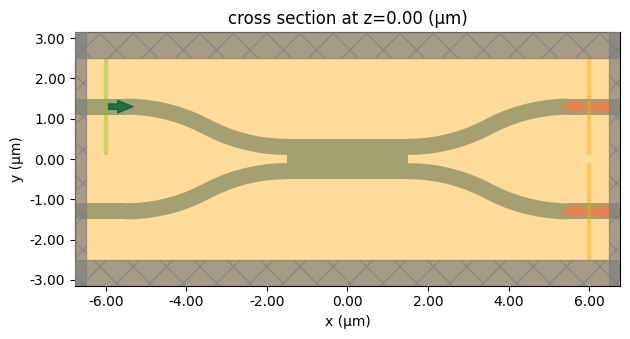

In [13]:
# Simulation Setup Visualization - XY Setup Plane
fig_xy = sim_mmi.plot(z=0)  # XY cross-section at z=0 (MMI center) - shows complete setup

In [14]:
# 3D Visualization
fig_3d = sim_mmi.plot_3d()

## Cost Estimation

Before running the simulation, let's estimate the computational cost.

In [15]:
# Cost Estimation
job = web.Job(simulation=sim_mmi, task_name="mmi_2x2_cost_estimation", verbose=True)
cost_info = web.estimate_cost(job.task_id)
print(f"Estimated cost: {cost_info:.4f} Flex Credits")

19:14:42 -03 Created task 'mmi_2x2_cost_estimation' with resource_id            
             'fdve-735fc2c7-f6a6-4ff8-9072-8a2c7875bc0e' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=920081;https://tidy3d.simulation.cloud/workbench?taskId=fdve-735fc2c7-f6a6-4ff8-9072-8a2c7875bc0e\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=43111;https://tidy3d.simulation.cloud/workbench?taskId=fdve-735fc2c7-f6a6-4ff8-9072-8a2c7875bc0e\taskId]8;;\]8;id=920081;https://tidy3d.simulation.cloud/workbench?taskId=fdve-735fc2c7-f6a6-4ff8-9072-8a2c7875bc0e\=]8;;\]8;id=82181;https://tidy3d.simulation.cloud/workbench?taskId=fdve-735fc2c7-f6a6-4ff8-9072-8a2c7875bc0e\fdve]8;;\]8;id=920081;https://tidy3d.simulation.cloud/workbench?taskId=fdve-735fc2c7-f6a6-4ff8-9072-8a2c7875bc0e\-735fc2c7-f6a]8;;\
             ]8;id=920081;https://tidy3d.simulation.cloud/workbench?taskId=fdve-735fc2c7-f6a6-4ff8-9072-8a2c7875bc0e\6-4ff8-9072-8a2c7875bc0e']8;;\.

             Task folder: ]8;id=279406;https://tidy3d.simulation.cloud/folders/folder-431883bc-afbb-4cc8-a95f-ddfeaeeb059a\'default']8;;\.

Output()

19:14:47 -03 Estimated FlexCredit cost: 0.077. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

Estimated cost: 0.0774 Flex Credits


## Run Simulation

Now we run the simulation to obtain the results.

In [16]:
# Run Simulation
sim_data = job.run(path="mmi_2x2_results.hdf5")

19:14:48 -03 Estimated FlexCredit cost: 0.077. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

19:14:51 -03 status = queued

             To cancel the simulation, use 'web.abort(task_id)' or              
             'web.delete(task_id)' or abort/delete the task in the web UI.      
             Terminating the Python script will not stop the job running on the 
             cloud.

Output()

19:14:55 -03 status = preprocess

19:15:00 -03 starting up solver

             running solver

Output()

19:15:20 -03 early shutoff detected at 36%, exiting.

19:15:21 -03 status = postprocess

Output()

19:15:24 -03 status = success

19:15:26 -03 View simulation result at                                          
             ]8;id=15703;https://tidy3d.simulation.cloud/workbench?taskId=fdve-735fc2c7-f6a6-4ff8-9072-8a2c7875bc0e\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=592935;https://tidy3d.simulation.cloud/workbench?taskId=fdve-735fc2c7-f6a6-4ff8-9072-8a2c7875bc0e\taskId]8;;\]8;id=15703;https://tidy3d.simulation.cloud/workbench?taskId=fdve-735fc2c7-f6a6-4ff8-9072-8a2c7875bc0e\=]8;;\]8;id=141249;https://tidy3d.simulation.cloud/workbench?taskId=fdve-735fc2c7-f6a6-4ff8-9072-8a2c7875bc0e\fdve]8;;\]8;id=15703;https://tidy3d.simulation.cloud/workbench?taskId=fdve-735fc2c7-f6a6-4ff8-9072-8a2c7875bc0e\-735fc2c7-f6a]8;;\
             ]8;id=15703;https://tidy3d.simulation.cloud/workbench?taskId=fdve-735fc2c7-f6a6-4ff8-9072-8a2c7875bc0e\6-4ff8-9072-8a2c7875bc0e']8;;\.

Output()

19:15:32 -03 Loading simulation from mmi_2x2_results.hdf5

## Result Analysis

Let's analyze the simulation results to evaluate the MMI power splitter performance.

**Key Performance Metrics:**

- **Power Splitting Ratio**: The fraction of total power that goes to each output port. For an ideal 2x2 MMI power splitter, both outputs should have a splitting ratio of 0.5 (50/50 split).

- **Total Power**: The sum of power from both output ports, showing the overall transmission efficiency of the device.

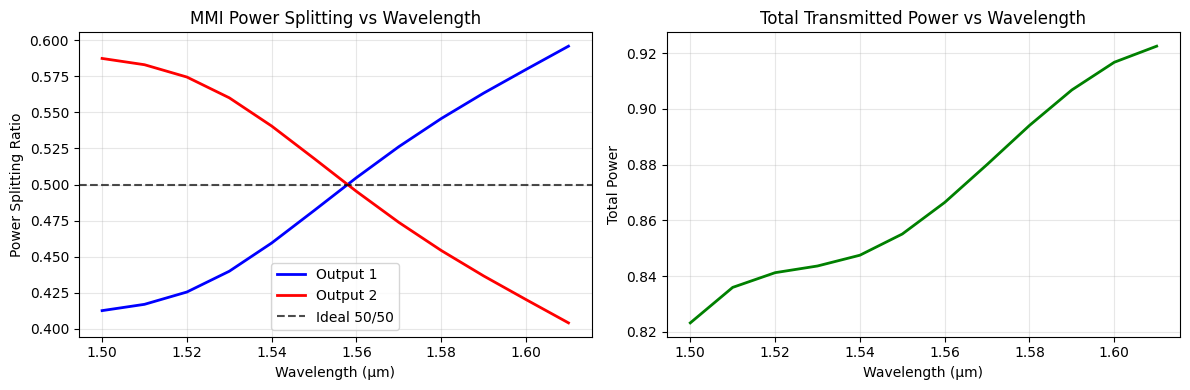

Average splitting ratio 1: 0.496
Average splitting ratio 2: 0.504
Average total power: 0.869


In [17]:
# Extract mode coefficients from ModeMonitors
mode_coeff_1 = sim_data["mode_output_1"].amps.sel(mode_index=0, direction="+")
mode_coeff_2 = sim_data["mode_output_2"].amps.sel(mode_index=0, direction="+")

# Calculate power splitting
power_1 = np.abs(mode_coeff_1) ** 2
power_2 = np.abs(mode_coeff_2) ** 2
total_power = power_1 + power_2

# Calculate splitting ratio
splitting_ratio_1 = power_1 / total_power
splitting_ratio_2 = power_2 / total_power

# Ensure arrays are numpy arrays for consistent indexing
splitting_ratio_1 = np.array(splitting_ratio_1)
splitting_ratio_2 = np.array(splitting_ratio_2)
total_power = np.array(total_power)

# Create comprehensive analysis plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Power splitting vs wavelength
ax1.plot(wavelengths, splitting_ratio_1, "b-", label="Output 1", linewidth=2)
ax1.plot(wavelengths, splitting_ratio_2, "r-", label="Output 2", linewidth=2)
ax1.axhline(y=0.5, color="k", linestyle="--", alpha=0.7, label="Ideal 50/50")
ax1.set_xlabel("Wavelength (μm)")
ax1.set_ylabel("Power Splitting Ratio")
ax1.set_title("MMI Power Splitting vs Wavelength")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Total power vs wavelength
ax2.plot(wavelengths, total_power, "g-", linewidth=2)
ax2.set_xlabel("Wavelength (μm)")
ax2.set_ylabel("Total Power")
ax2.set_title("Total Transmitted Power vs Wavelength")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print key performance metrics
print(f"Average splitting ratio 1: {splitting_ratio_1.mean():.3f}")
print(f"Average splitting ratio 2: {splitting_ratio_2.mean():.3f}")
print(f"Average total power: {total_power.mean():.3f}")

**Power Splitting Performance Analysis:**

The power splitting ratio plot reveals several important characteristics of the MMI power splitter:

- **Optimal Operating Wavelength**: The device achieves perfect 50/50 splitting at approximately 1.58 μm, where both output curves intersect the ideal 50/50 line.

- **Wavelength Dependence**: The splitting ratio shows significant wavelength dependence:
  - At shorter wavelengths (1.50 μm): Output 2 receives ~62% of power, Output 1 receives ~37%
  - At longer wavelengths (1.60 μm): Output 1 receives ~54% of power, Output 2 receives ~46%

- **Design Implications**: This wavelength dependence is typical for MMI devices and can be optimized by adjusting the MMI length, width, or using apodization techniques for broader bandwidth performance.

## Field Intensity Analysis

Finally, let's examine the field intensity distribution at specific wavelengths in the XY plane to understand the light propagation through the MMI.

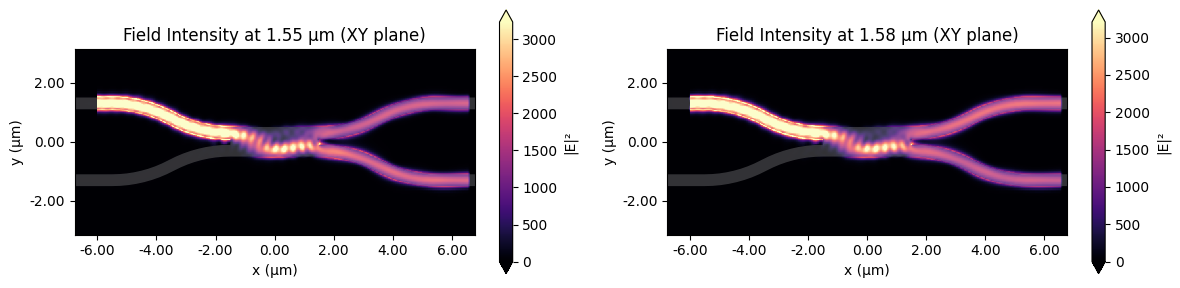

In [18]:
# Create a 2x1 subplot for the two wavelengths.
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Plot field intensity at 1.55 um using Tidy3D's built-in method.
sim_data.plot_field("field_xy", "E", val="abs^2", f=td.C_0 / 1.55, ax=axes[0])
axes[0].set_title("Field Intensity at 1.55 μm (XY plane)")

# Plot field intensity at 1.58 um using Tidy3D's built-in method.
sim_data.plot_field("field_xy", "E", val="abs^2", f=td.C_0 / 1.58, ax=axes[1])
axes[1].set_title("Field Intensity at 1.58 μm (XY plane)")

plt.tight_layout()
plt.show()